## Libraries<a href="#Libraries" class="anchor-link">¶</a>

In \[1\]:

    import yfinance as yf
    import pandas as pd
    import numpy as np
    import math
    import matplotlib.pyplot as plt
    import scipy.optimize as optimal
    from matplotlib.pyplot import figure
    from prettytable import PrettyTable
    from tabulate import tabulate
    from IPython.display import display
    import cvxpy as cp
    import copy
    import warnings
    warnings.filterwarnings("ignore")

## 1. Introduction<a href="#1.-Introduction" class="anchor-link">¶</a>

### Research Question<a href="#Research-Question" class="anchor-link">¶</a>

This project assesses whether a portfolio allocation based on the **Kelly Criterion Method** can improve performance in a momentum-based investment strategy. Momentum investing is based on the idea that assets that have performed well in the recent past may continue to perform well in the short term. Using this idea, stocks are classified according to their momentum signals and combined into a trading strategy.

While many momentum strategies allocate capital equally across selected assets, the Kelly Criterion offers an alternative approach that determines position sizes based on expected return and variance. In theory, this method maximizes long-term portfolio growth by allocating more capital to assets with stronger risk-adjusted return characteristics.

The central question guiding this analysis is:

**Can a Kelly Criterion portfolio allocation based on momentum signals outperform an equal-weight momentum portfolio while maintaining reasonable levels of risk?**

To explore this question, I construct momentum signals from historical return data, build portfolios using both equal weighting and Kelly-based allocation, and compare their performance over time. The goal is to evaluate whether the Kelly approach provides a meaningful improvement in portfolio growth while understanding the potential risks associated with more concentrated allocations.

## 2. Data Description<a href="#2.-Data-Description" class="anchor-link">¶</a>

The dataset used in this analysis contains historical price data for a set of publicly traded stocks. Each observation represents the daily market information for a specific asset over the sample period used to construct the momentum signals and portfolio returns.

The dataset includes the following variables:
• Date – the trading day corresponding to each observation.
• Price variables – daily price information used to compute returns.
• Ticker or asset identifier – identifies each stock included in the analysis.

The dataset covers a defined time period and includes multiple stocks that form the investment universe for the momentum strategy. Each asset contributes a time series of prices that allows returns and momentum signals to be calculated.

Before constructing the momentum strategy, several preprocessing steps are applied to prepare the data for analysis. First, price data are organized into a time series structure so that returns can be computed consistently across all assets. Missing observations are removed or handled to ensure that calculations are performed on complete data.

Daily percentage returns are then calculated from price data to measure how each asset changes in value from one trading day to the next. Percentage returns are used because they allow returns from different assets to be compared on a consistent scale and can be aggregated to evaluate portfolio performance.

After returns are calculated, they are used to construct the momentum signal, which measures recent performance and determines which assets are selected for the trading strategy.

This preprocessing step ensures that the data are clean, consistent, and suitable for building the momentum portfolios and evaluating the Kelly allocation method.

### 3. Exploratory Data Analysis (EDA)<a href="#3.-Exploratory-Data-Analysis-(EDA)" class="anchor-link">¶</a>

Before constructing the momentum strategy and applying the Kelly allocation method, it is useful to examine the statistical properties of the return data. Exploratory Data Analysis helps identify patterns, volatility differences across assets, and relationships between variables that may influence portfolio construction.

**Distribution of Returns**

The distribution of daily returns provides insight into the behavior of the assets included in the investment universe. Financial return series often display fat tails, meaning extreme positive and negative returns occur more frequently than they would in a normal distribution. Examining this distribution helps determine whether the data contain unusually large movements that could influence portfolio performance.

Understanding the shape of the return distribution is particularly important when applying the Kelly Criterion, because the allocation weights depend heavily on estimates of expected return and variance. Large outliers or heavy-tailed distributions can introduce estimation noise, which may cause the Kelly method to allocate a disproportionate share of capital to a small number of assets.

**Volatility Across Assets**
Another important characteristic of the dataset is the level of volatility associated with each asset. Volatility measures how widely returns fluctuate over time and is commonly used as a proxy for financial risk. Comparing volatility across assets helps identify which stocks contribute the most uncertainty to the portfolio.

Assets with higher volatility may receive smaller allocations under risk-adjusted frameworks, while assets with lower volatility may appear more attractive depending on their expected return.

**Correlation Between Assets**
A correlation analysis helps evaluate how strongly the returns of different assets move together. Highly correlated assets provide less diversification because their returns tend to rise and fall at the same time. Lower correlations can improve diversification and reduce overall portfolio risk.

Examining the correlation structure is useful when constructing portfolios, because diversification benefits depend on selecting assets whose returns are not perfectly aligned.

**Momentum Score Distribution**
Finally, the distribution of the calculated momentum scores is examined. Momentum scores represent recent performance and determine which assets are selected for long or short positions in the strategy.

Understanding how these scores are distributed helps evaluate whether the strategy produces clear separation between strong and weak performers or whether most assets cluster around similar momentum values.

Together, these exploratory analyses provide a statistical overview of the dataset and help ensure that the momentum strategy and Kelly allocation are applied to data whose behavior is well understood.

## 4. Momentum Strategy<a href="#4.-Momentum-Strategy" class="anchor-link">¶</a>

The momentum strategy used in this analysis is based on the idea that assets with strong recent performance may continue to perform well in the near future, while assets with weak recent performance may continue to underperform.

Momentum investing is commonly discussed in academic finance literature as a factor where assets that have performed well over a recent period tend to continue performing well in the short term, while poorly performing assets may continue to lag.
To implement this idea, momentum scores are calculated using historical return data. For each asset, recent returns over a specified lookback window are used to measure its recent performance. Assets with higher momentum scores indicate stronger recent performance, while lower momentum scores indicate weaker performance.

Using these scores, assets are separated into two groups:

• **Long positions**: assets with the strongest positive momentum scores. These are expected to continue performing well and are included in the long portfolio.

• **Short positions**: assets with the weakest momentum scores. These assets represent recent underperformers and are included in the short portfolio.

This classification produces a **long–short momentum portfolio**, where capital is allocated to assets with positive momentum while short positions are taken in assets with negative momentum. The goal of this approach is to capture the spread between recent winners and losers.
In this implementation, momentum signals derived from historical returns determine which assets are included in each group. Once the assets are classified, portfolio weights are assigned either through equal weighting or through the Kelly Criterion allocation method examined later in the analysis.

This approach approximates the general concept of factor-based momentum investing by systematically selecting assets based on their recent performance and evaluating how different allocation methods influence overall portfolio growth.

In \[2\]:

    portfolio = ['spy','goog','amzn','msft','bac','pg','vz','tsla','gs','nvda','mrna','pfe','xom','cvx','ba']

In \[3\]:

    rf_rate = 4.10 / 100
    hours_per_year = 8760
    rf_hour = rf_rate / hours_per_year

    display(
        pd.DataFrame({
            "Annual Risk-Free Rate":
            [rf_rate],
            "Hours per Year":
            [hours_per_year],
            "Hourly Risk-Free Rate":
            [rf_hour]
        }).style.format({
            "Annual Risk-Free Rate":
            "{:.2%}",
            "Hourly Risk-Free Rate":
            "{:.8f}"
        })
        .hide(axis="index")
    )

<style type="text/css">
</style>

| Annual Risk-Free Rate | Hours per Year | Hourly Risk-Free Rate |
|-----------------------|----------------|-----------------------|
| 4.10%                 | 8760           | 0.00000468            |

In \[4\]:

    #Download price data
    data = yf.download(
        portfolio,
        start="2015-01-01",
        progress=False
    )

    #Use closing prices to compute asset returns
    prices = data["Close"]  #or data["Close"]

    #Convert risk free rate to hourly rate
    rf_hour = rf_rate / hours_per_year

    #Compute returns
    R = prices.pct_change()

    #Compute excess returns
    ExcessReturn = R.dropna() - rf_hour

    #Convert to numpy matrix
    Rt = ExcessReturn.to_numpy()

    #Define dimensions
    T = Rt.shape[0] #number of observations
    N = Rt.shape[1] #number of assets
    M = 120 #rolling estimation window (120 observations used to estimate portfolio weights)

#### Excess Return Matrix<a href="#Excess-Return-Matrix" class="anchor-link">¶</a>

**A record of hourly excess returns for all stocks in your portfolio.**

**Observation**

Each row = one observation in time (one hour in the dataset)

• Each column = a different stock

• Each number = that stock’s excess return during that hour

#### This section prepares the return data for portfolio optimization by converting it to a numerical matrix and defining the dataset dimensions and rolling window length.<a href="#This-section-prepares-the-return-data-for-portfolio-optimization-by-converting-it-to-a-numerical-matrix-and-defining-the-dataset-dimensions-and-rolling-window-length." class="anchor-link">¶</a>

In \[5\]:

    #Define portfolio weight function
    def getweight(N,T,M,R,method,r=0.002,gamma=5,delta=0.01):

        weight = np.full((T,N),np.nan,dtype=float)
        data = np.lib.stride_tricks.sliding_window_view(R,(M,N))

        if method == "ew":
            weight[:] = 1.0/N
            weight[:M-1] = np.nan

        return weight

    #Compute portfolio weights using equal weight strategy
    W = getweight(N, T, M, Rt, "ew")

    #Display excess return matrix
    pd.DataFrame(Rt, columns=ExcessReturn.columns).head() \
        .style.format("{:.6f}") \
        .set_properties(**{"text-align": "center"})

Out\[5\]:

<style type="text/css">
#T_44561_row0_col0, #T_44561_row0_col1, #T_44561_row0_col2, #T_44561_row0_col3, #T_44561_row0_col4, #T_44561_row0_col5, #T_44561_row0_col6, #T_44561_row0_col7, #T_44561_row0_col8, #T_44561_row0_col9, #T_44561_row0_col10, #T_44561_row0_col11, #T_44561_row0_col12, #T_44561_row0_col13, #T_44561_row0_col14, #T_44561_row1_col0, #T_44561_row1_col1, #T_44561_row1_col2, #T_44561_row1_col3, #T_44561_row1_col4, #T_44561_row1_col5, #T_44561_row1_col6, #T_44561_row1_col7, #T_44561_row1_col8, #T_44561_row1_col9, #T_44561_row1_col10, #T_44561_row1_col11, #T_44561_row1_col12, #T_44561_row1_col13, #T_44561_row1_col14, #T_44561_row2_col0, #T_44561_row2_col1, #T_44561_row2_col2, #T_44561_row2_col3, #T_44561_row2_col4, #T_44561_row2_col5, #T_44561_row2_col6, #T_44561_row2_col7, #T_44561_row2_col8, #T_44561_row2_col9, #T_44561_row2_col10, #T_44561_row2_col11, #T_44561_row2_col12, #T_44561_row2_col13, #T_44561_row2_col14, #T_44561_row3_col0, #T_44561_row3_col1, #T_44561_row3_col2, #T_44561_row3_col3, #T_44561_row3_col4, #T_44561_row3_col5, #T_44561_row3_col6, #T_44561_row3_col7, #T_44561_row3_col8, #T_44561_row3_col9, #T_44561_row3_col10, #T_44561_row3_col11, #T_44561_row3_col12, #T_44561_row3_col13, #T_44561_row3_col14, #T_44561_row4_col0, #T_44561_row4_col1, #T_44561_row4_col2, #T_44561_row4_col3, #T_44561_row4_col4, #T_44561_row4_col5, #T_44561_row4_col6, #T_44561_row4_col7, #T_44561_row4_col8, #T_44561_row4_col9, #T_44561_row4_col10, #T_44561_row4_col11, #T_44561_row4_col12, #T_44561_row4_col13, #T_44561_row4_col14 {
  text-align: center;
}
</style>

| Ticker | AMZN | BA | BAC | CVX | GOOG | GS | MRNA | MSFT | NVDA | PFE | PG | SPY | TSLA | VZ | XOM |
|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|
| 0 | 0.007300 | 0.009679 | -0.026351 | -0.004767 | 0.002861 | -0.004680 | 0.010748 | 0.026422 | 0.028788 | 0.010924 | 0.006269 | 0.001893 | 0.020053 | 0.010224 | -0.014173 |
| 1 | 0.001342 | -0.013242 | -0.007275 | 0.004606 | 0.011731 | -0.011356 | -0.042026 | 0.009290 | -0.024172 | -0.008788 | 0.009454 | 0.000223 | 0.004404 | 0.009949 | 0.001824 |
| 2 | 0.012349 | 0.014466 | -0.002445 | 0.001294 | 0.011338 | -0.000570 | 0.037197 | 0.004508 | 0.004786 | 0.003404 | 0.001273 | 0.005030 | -0.000441 | -0.027193 | -0.008612 |
| 3 | -0.003107 | -0.003739 | -0.004899 | 0.002763 | -0.001678 | -0.004419 | 0.004278 | 0.003387 | -0.000072 | 0.009279 | 0.026157 | -0.000344 | 0.027791 | -0.002799 | 0.012624 |
| 4 | -0.040086 | -0.020652 | 0.003274 | -0.018204 | -0.018650 | -0.017910 | -0.023459 | -0.031252 | -0.016393 | -0.017281 | 0.001550 | -0.018469 | -0.029411 | -0.000179 | -0.018191 |

In \[17\]:

    def getweight(N,T,M,R,method,r=0.002,gamma=5,delta=0.01):

        #set_weight_and_windows
        weight = np.full((T,N),np.nan,dtype=float)
        data = np.lib.stride_tricks.sliding_window_view(R,(M,N))

        #1 Equal Weight
        if method == "ew":
            weight[:] = 1.0/N
            weight[:M-1] = np.nan

        #2 Mean Variance
        elif method == "mv":
            for i in range(data.shape[0]):
                X = data[i][0]
                mu = np.mean(X,axis=0)
                sigma = np.cov(X.T) + 1e-6*np.eye(N)
                weight[i+M-1] = (1.0/gamma) * np.linalg.solve(sigma,mu)

        #3 Unbiased Mean Variance
        elif method == "u-mv":
            if M <= N+2:
                raise ValueError("u-mv requires M > N+2")
            adj = (M-N-2)/(M-1)
            for i in range(data.shape[0]):
                X = data[i][0]
                mu = np.mean(X,axis=0)
                sigma = np.cov(X.T) + 1e-6*np.eye(N)
                weight[i+M-1] = (1.0/gamma) * adj * np.linalg.solve(sigma,mu)

        #4 Minimum Variance
        elif method == "min":
            for i in range(data.shape[0]):
                X = data[i][0]
                sigma = np.cov(X.T) + 1e-6*np.eye(N)
                e = np.ones(N)
                inv_e = np.linalg.solve(sigma,e)
                weight[i+M-1] = inv_e/(e@inv_e)

        #5 Pair Trading
        elif method == "pt":
            for i in range(data.shape[0]):
                X = data[i][0]
                mu = np.mean(X,axis=0)
                std = np.std(X,axis=0,ddof=0)
                last = X[-1]
                upper = mu + 2*std
                lower = mu - 2*std
                w = np.zeros(N)
                w[last >= upper] = -1.0
                w[last <= lower] = 1.0
                s = np.sum(np.abs(w))
                if s > 0:
                    w = w/s
                weight[i+M-1] = w

        #6 Kelly Criterion
        elif method == "kelly":
            for i in range(data.shape[0]):
                X = data[i][0]
                mu = np.mean(X,axis=0)
                sigma = np.cov(X.T) + 1e-6*np.eye(N)
                w = np.linalg.solve(sigma,mu)
                denom = np.sum(np.abs(w))
                if denom > 0:
                    w = w/denom
                weight[i+M-1] = w

        else:
            raise ValueError(f"Unknown method: {method}")

        return weight

### Run the Portfolio method<a href="#Run-the-Portfolio-method" class="anchor-link">¶</a>

In \[ \]:

     

In \[ \]:

     

In \[19\]:

    weights_kelly = getweight(N, T, M, Rt, "kelly")

    kelly_df = pd.DataFrame(weights_kelly, columns=portfolio).dropna()

In \[ \]:

     

In \[20\]:

    display(kelly_df.head(1).style.set_caption("Kelly"))

<style type="text/css">
</style>

|   | spy | goog | amzn | msft | bac | pg | vz | tsla | gs | nvda | mrna | pfe | xom | cvx | ba |
|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|
| 119 | -0.021693 | 0.004719 | 0.040187 | 0.052690 | -0.042322 | -0.064696 | 0.006537 | 0.074660 | -0.014348 | -0.087841 | 0.105182 | 0.249531 | -0.066129 | -0.042183 | -0.127284 |

Kelly {#T_e701b}

**Observation**

Each value represents the proportion of total portfolio capital invested in the corresponding stock.

### Check that weights sum to 1<a href="#Check-that-weights-sum-to-1" class="anchor-link">¶</a>

In \[21\]:

    kelly_df = pd.DataFrame(weights_kelly, columns=portfolio)

    kelly_df.dropna().head(1).abs().sum(axis=1) #Kellyweightsarenormalizedbyabsoluteexposure(sum|w|=1)

Out\[21\]:

    119    1.0
    dtype: float64

In \[37\]:

    def _check_shapes(R, W, M, T):
        #checks
        if not (isinstance(M, int) and isinstance(T, int)):
            raise TypeError("M and T must be integers")
        if M < 1 or T <= M:
            raise ValueError("Need M>=1 and T>M")
        if R.shape != W.shape:
            raise ValueError(f"R and W must have same shape, got R{R.shape} vs W{W.shape}")
        if T > R.shape[0]:
            raise ValueError(f"T={T} exceeds available rows {R.shape[0]}")
        return True

    def Turnover(R, W, M, T, r):
        #turnover
        _check_shapes(R, W, M, T)
        R_new = 1.0 + R
        turnover_t = []

        for t in range(M - 1, T - 1):
            wj = W[t, :]
            denom = np.sum(wj * R_new[t, :]) + (1.0 - np.sum(wj)) * (1.0 + r)
            wj_bef_rebal = (wj * R_new[t, :]) / denom
            turnover = np.sum(np.abs(W[t + 1, :] - wj_bef_rebal))
            turnover_t.append(turnover)

        return float(np.mean(turnover_t)) if turnover_t else np.nan

    def OSR(R, W, M, T, ddof=0):
        #overallsharpe
        _check_shapes(R, W, M, T)
        w_R = W[M - 1:T, :] * R[M - 1:T, :]
        mu_t = np.sum(w_R, axis=1)
        sd = np.std(mu_t, ddof=ddof)
        return float(np.mean(mu_t) / sd) if sd != 0 else np.nan

    def ISR(R, W, M, T, ddof=0):
        #informationsharpe
        _check_shapes(R, W, M, T)
        #assumption: last column is the benchmark (eg SPY), others are active assets
        active = slice(0, W.shape[1] - 1)
        bench = W.shape[1] - 1

        active_ret = np.sum(W[M - 1:T, active] * R[M - 1:T, active], axis=1)
        bench_ret = W[M - 1:T, bench] * R[M - 1:T, bench]
        excess = active_ret - bench_ret

        sd = np.std(excess, ddof=ddof)
        return float(np.mean(excess) / sd) if sd != 0 else np.nan

    def sortino(R, W, M, T, ddof=0):
        #sortino
        _check_shapes(R, W, M, T)
        mu_t = np.sum(W[M - 1:T, :] * R[M - 1:T, :], axis=1)
        mean_ret = np.mean(mu_t)
        downside = np.minimum(mu_t, 0.0)
        dd_down = np.sqrt(np.mean(downside**2))
        return float(mean_ret / dd_down) if dd_down != 0 else np.nan

    def VaR(R, W, M, T, alpha=0.05):
        #varcvar
        _check_shapes(R, W, M, T)
        mu_t = np.sum(W[M - 1:T, :] * R[M - 1:T, :], axis=1)
        var = np.quantile(mu_t, alpha)
        cvar = mu_t[mu_t <= var].mean() if np.any(mu_t <= var) else var
        return float(-var), float(-cvar)

    def max_drawdown(R, W, M, T):
        #maxdrawdowncalmar
        _check_shapes(R, W, M, T)
        mu_t = pd.Series(np.sum(W[M - 1:T, :] * R[M - 1:T, :], axis=1))
        comp_ret = (1.0 + mu_t).cumprod()
        peak = comp_ret.cummax()
        dd_series = comp_ret / peak - 1.0
        dd = float(dd_series.min())
        calmar = float(mu_t.mean() / abs(dd)) if dd != 0 else np.nan
        return dd, calmar

    def omega(R, W, M, T):
        #omega
        _check_shapes(R, W, M, T)
        mu_t = np.sum(W[M - 1:T, :] * R[M - 1:T, :], axis=1)
        gains = np.sum(mu_t[mu_t > 0.0])
        losses = -np.sum(mu_t[mu_t < 0.0])
        return float(gains / losses) if losses != 0 else np.nan

In \[38\]:

    i=1
    xcoordinates=[]
    experiment_1_turnover=[]
    experiment_1_isr=[]
    experiment_1_osr=[]
    sortinolist=[]
    VaRlist=[]
    max_drawdownlist=[]
    omegalist=[]

In \[39\]:

    methods = ["ew","mv","u-mv","min","pt","kelly"]
    tick_label = methods

In \[106\]:

    data_l = Rt
    T = Rt.shape[0]
    N = Rt.shape[1]
    M = 120

    experiment_1_turnover = []
    experiment_1_isr = []
    experiment_1_osr = []
    sortinolist = []
    VaRlist = []
    max_drawdownlist = []
    omegalist = []
    xcoordinates = []

    valid_methods = {"ew","mv","u-mv","min","pt","kelly"}

    for i, method in enumerate(methods, start=1):

        if method not in valid_methods:
            raise ValueError(f"Method list contains unsupported method: {method}")

        print(f"{method} outcome")

        weight1 = getweight(N, T, M, data_l, method)

        answer0 = Turnover(data_l, weight1, M, T, r=rf_hour)
        answer1 = ISR(data_l, weight1, M, T)
        answer2 = OSR(data_l, weight1, M, T)
        answer5 = sortino(data_l, weight1, M, T)
        answer6 = VaR(data_l, weight1, M, T)
        answer7 = max_drawdown(data_l, weight1, M, T)
        answer8 = omega(data_l, weight1, M, T)

        experiment_1_turnover.append(answer0)
        experiment_1_isr.append(answer1)
        experiment_1_osr.append(answer2)
        sortinolist.append(answer5)
        VaRlist.append(answer6)
        max_drawdownlist.append(answer7)
        omegalist.append(answer8)

        xcoordinates.append(i)

    ew outcome
    mv outcome
    u-mv outcome
    min outcome
    pt outcome
    kelly outcome

In \[107\]:

    results_df = pd.DataFrame({
        "Method": methods,
        "Turnover": experiment_1_turnover,
        "ISR": experiment_1_isr,
        "OSR": experiment_1_osr
    })

    display(
        results_df.style
            .format({
                "Turnover": "{:.4f}",
                "ISR": "{:.4f}",
                "OSR": "{:.4f}"
            })
            .set_properties(**{"text-align": "center"})
            .hide(axis="index")
    )

<style type="text/css">
#T_1f7df_row0_col0, #T_1f7df_row0_col1, #T_1f7df_row0_col2, #T_1f7df_row0_col3, #T_1f7df_row1_col0, #T_1f7df_row1_col1, #T_1f7df_row1_col2, #T_1f7df_row1_col3, #T_1f7df_row2_col0, #T_1f7df_row2_col1, #T_1f7df_row2_col2, #T_1f7df_row2_col3, #T_1f7df_row3_col0, #T_1f7df_row3_col1, #T_1f7df_row3_col2, #T_1f7df_row3_col3, #T_1f7df_row4_col0, #T_1f7df_row4_col1, #T_1f7df_row4_col2, #T_1f7df_row4_col3, #T_1f7df_row5_col0, #T_1f7df_row5_col1, #T_1f7df_row5_col2, #T_1f7df_row5_col3 {
  text-align: center;
}
</style>

| Method | Turnover | ISR     | OSR     |
|--------|----------|---------|---------|
| ew     | 0.0133   | 0.0719  | 0.0732  |
| mv     | 3.9326   | 0.2024  | 0.3943  |
| u-mv   | 3.3228   | 0.2024  | 0.3943  |
| min    | 0.1183   | 0.0288  | 0.0430  |
| pt     | 0.7498   | -0.5737 | -0.6388 |
| kelly  | 0.1595   | 0.1957  | 0.3631  |

In \[108\]:

    results_df_2 = pd.DataFrame({
        "Method": methods,
        "Sortino": sortinolist,
        "VaR": [v[0] for v in VaRlist],
        "CVaR": [v[1] for v in VaRlist]
    })

    display(
        results_df_2.style
            .format({"Sortino": "{:.4f}", "VaR": "{:.4f}", "CVaR": "{:.4f}"})
            .set_properties(**{"text-align": "center"})
            .hide(axis="index")
    )

<style type="text/css">
#T_0526b_row0_col0, #T_0526b_row0_col1, #T_0526b_row0_col2, #T_0526b_row0_col3, #T_0526b_row1_col0, #T_0526b_row1_col1, #T_0526b_row1_col2, #T_0526b_row1_col3, #T_0526b_row2_col0, #T_0526b_row2_col1, #T_0526b_row2_col2, #T_0526b_row2_col3, #T_0526b_row3_col0, #T_0526b_row3_col1, #T_0526b_row3_col2, #T_0526b_row3_col3, #T_0526b_row4_col0, #T_0526b_row4_col1, #T_0526b_row4_col2, #T_0526b_row4_col3, #T_0526b_row5_col0, #T_0526b_row5_col1, #T_0526b_row5_col2, #T_0526b_row5_col3 {
  text-align: center;
}
</style>

| Method | Sortino | VaR    | CVaR   |
|--------|---------|--------|--------|
| ew     | 0.1046  | 0.0199 | 0.0331 |
| mv     | 0.8539  | 0.0866 | 0.1206 |
| u-mv   | 0.8539  | 0.0750 | 0.1044 |
| min    | 0.0628  | 0.0118 | 0.0171 |
| pt     | -0.5383 | 0.0887 | 0.1193 |
| kelly  | 0.7496  | 0.0043 | 0.0065 |

In \[109\]:

    results_df_3 = pd.DataFrame({
        "Method": methods,
        "Max Drawdown": [v[0] for v in max_drawdownlist],
        "Calmar": [v[1] for v in max_drawdownlist],
        "Omega": omegalist
    })

    display(
        results_df_3.style
            .format({
                "Max Drawdown": "{:.4f}",
                "Calmar": "{:.4f}",
                "Omega": "{:.4f}"
            })
            .set_properties(**{"text-align": "center"})
            .hide(axis="index")
    )

<style type="text/css">
#T_d7443_row0_col0, #T_d7443_row0_col1, #T_d7443_row0_col2, #T_d7443_row0_col3, #T_d7443_row1_col0, #T_d7443_row1_col1, #T_d7443_row1_col2, #T_d7443_row1_col3, #T_d7443_row2_col0, #T_d7443_row2_col1, #T_d7443_row2_col2, #T_d7443_row2_col3, #T_d7443_row3_col0, #T_d7443_row3_col1, #T_d7443_row3_col2, #T_d7443_row3_col3, #T_d7443_row4_col0, #T_d7443_row4_col1, #T_d7443_row4_col2, #T_d7443_row4_col3, #T_d7443_row5_col0, #T_d7443_row5_col1, #T_d7443_row5_col2, #T_d7443_row5_col3 {
  text-align: center;
}
</style>

| Method | Max Drawdown | Calmar  | Omega  |
|--------|--------------|---------|--------|
| ew     | -0.3298      | 0.0031  | 1.2412 |
| mv     | -0.4621      | 0.0680  | 2.8593 |
| u-mv   | -0.4119      | 0.0660  | 2.8593 |
| min    | -0.1974      | 0.0017  | 1.1276 |
| pt     | -1.0000      | -0.0215 | 0.0000 |
| kelly  | -0.0247      | 0.0576  | 2.7018 |

In \[110\]:

    plt.figure(figsize=(14,6))

    colors = plt.cm.Set2(np.linspace(0,1,len(methods)))

    bars = plt.bar(
        methods,
        experiment_1_turnover,
        color=colors,
        edgecolor="black",
        linewidth=0.7
    )

    plt.title("Turnover Comparison Across Portfolio Methods", fontsize=16, pad=15)
    plt.xlabel("Portfolio Method", fontsize=12)
    plt.ylabel("Turnover", fontsize=12)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.xticks(rotation=20)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

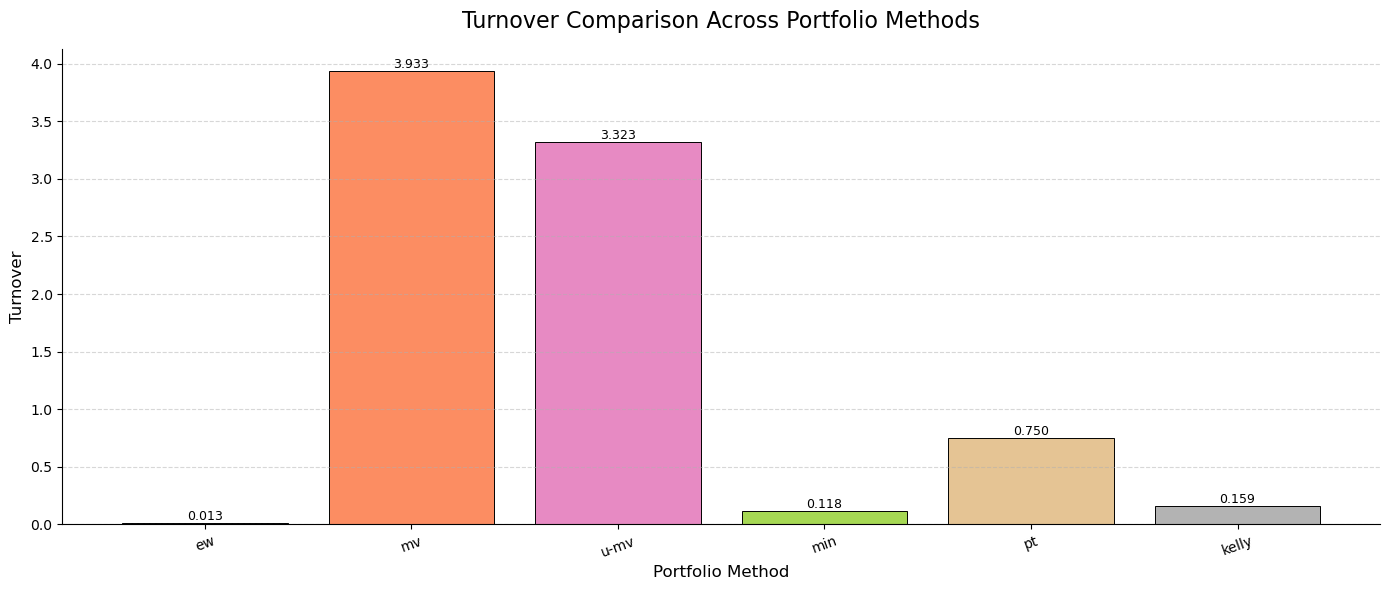

In \[111\]:

    plt.figure(figsize=(14,6))

    colors = plt.cm.Set2(np.linspace(0,1,len(xcoordinates)))

    bars = plt.bar(
        xcoordinates,
        experiment_1_isr,
        tick_label=tick_label,
        width=0.7,
        color=colors,
        edgecolor="black",
        linewidth=0.7
    )

    plt.xlabel("Portfolio Method", fontsize=12)
    plt.ylabel("ISR", fontsize=12)
    plt.title("Information Sharpe Ratio Comparison", fontsize=16, pad=15)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

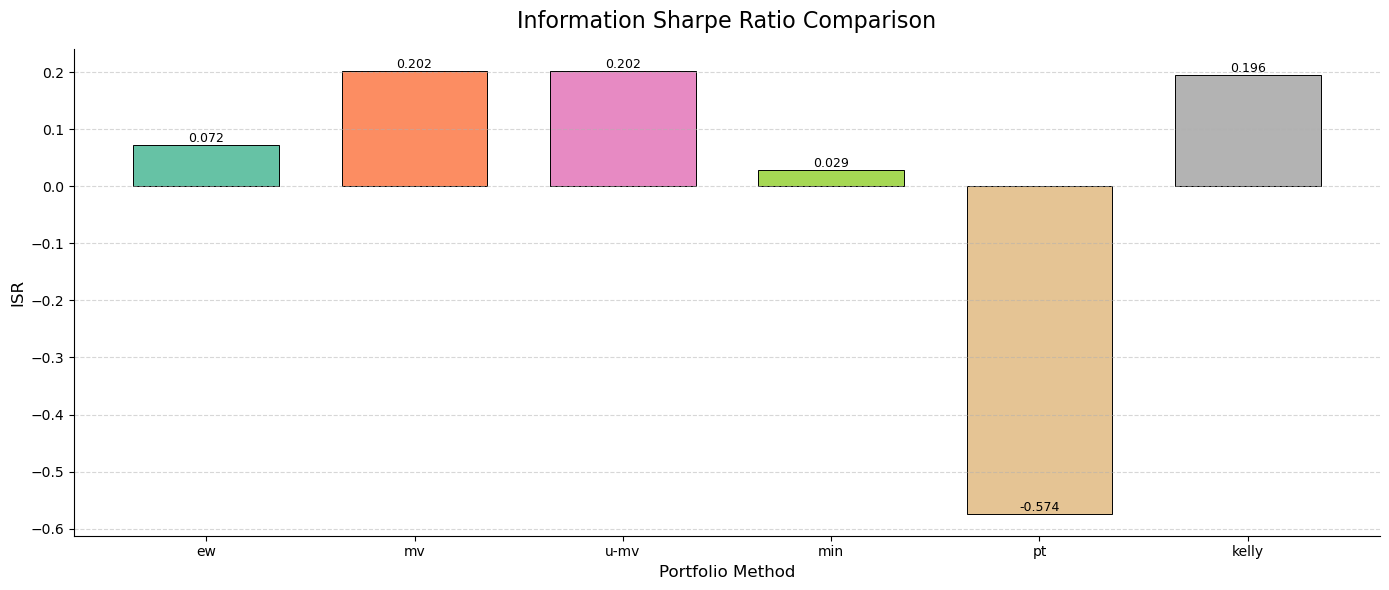

In \[112\]:

    plt.figure(figsize=(14,6))

    # colors
    bar_color = "#8c564b"
    line_color = "#1f77b4"

    # OSR bars
    bars = plt.bar(
        xcoordinates,
        experiment_1_osr,
        tick_label=tick_label,
        width=0.6,
        color=bar_color,
        edgecolor="black",
        label="OSR"
    )

    # ISR line
    plt.plot(
        xcoordinates,
        experiment_1_isr,
        marker="o",
        linewidth=2,
        color=line_color,
        label="ISR"
    )

    plt.xlabel("Portfolio Method", fontsize=12)
    plt.ylabel("Performance Metric", fontsize=12)
    plt.title("ISR vs OSR Comparison Across Portfolio Methods", fontsize=16, pad=15)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    # value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # remove top/right borders
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.legend()
    plt.tight_layout()
    plt.show()

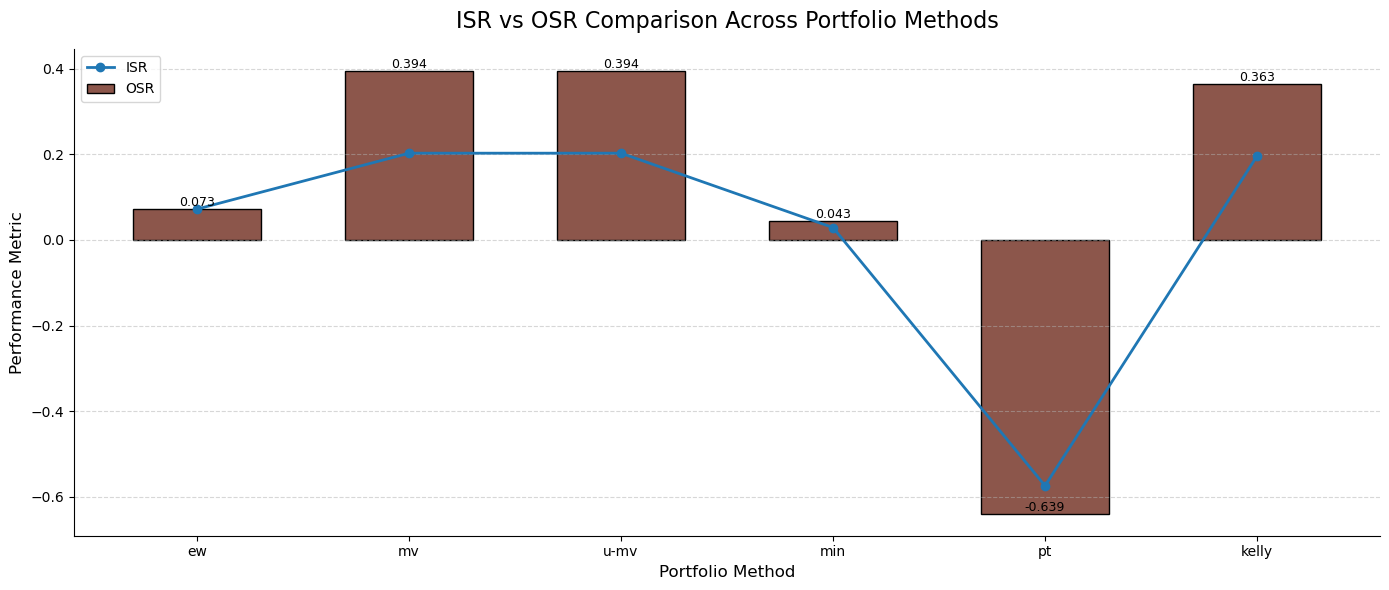

In \[113\]:

    plt.figure(figsize=(14,6))

    colors = plt.cm.Set2(np.linspace(0,1,len(xcoordinates)))

    bars = plt.bar(
        xcoordinates,
        sortinolist,
        tick_label=tick_label,
        width=0.7,
        color=colors,
        edgecolor="black",
        linewidth=0.7
    )

    plt.xlabel("Portfolio Method", fontsize=12)
    plt.ylabel("Sortino Ratio", fontsize=12)
    plt.title("Sortino Ratio Comparison Across Portfolio Methods", fontsize=16, pad=15)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

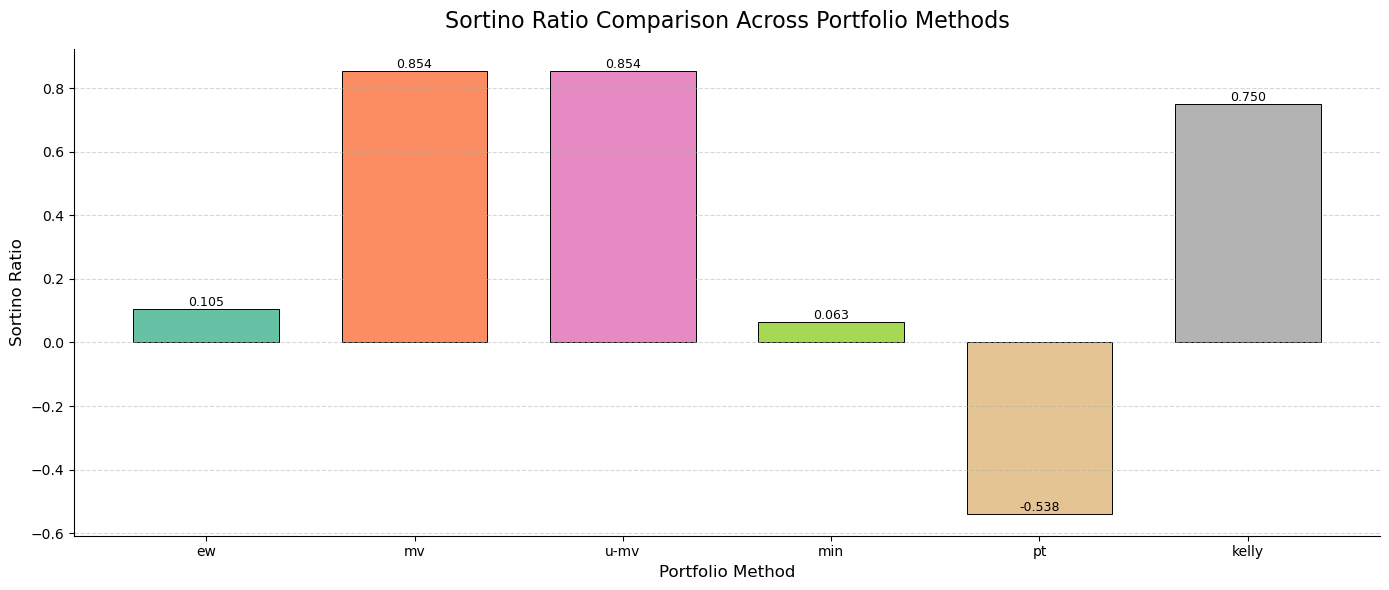

In \[114\]:

    plt.figure(figsize=(14,6))

    colors = plt.cm.Set2(np.linspace(0,1,len(xcoordinates)))

    bars = plt.bar(
        xcoordinates,
        omegalist,
        tick_label=tick_label,
        width=0.7,
        color=colors,
        edgecolor="black",
        linewidth=0.7
    )

    plt.xlabel("Portfolio Method", fontsize=12)
    plt.ylabel("Omega Ratio", fontsize=12)
    plt.title("Omega Ratio Comparison Across Portfolio Methods", fontsize=16, pad=15)

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

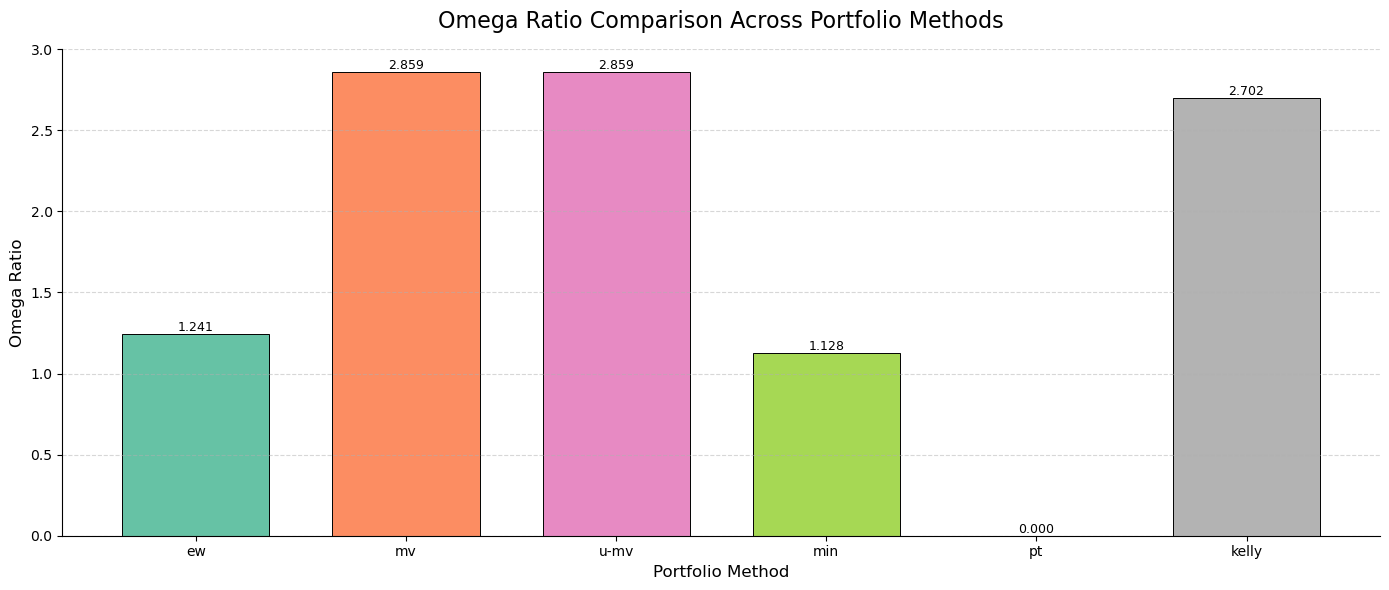